## [Luis Alejandro Rodríguez Arenas](https://luigitoby.github.io/)
## Cod. 202321287
# Taller 8

# Librerías

In [58]:
from sympy import symbols, Matrix, pi, cos, sin, simplify, eye, solve, latex, atan2, pprint, init_printing, Derivative, sqrt, diff, Eq, tan, integrate, lambdify, ln
from sympy.physics.vector import dynamicsymbols, init_vprinting, ReferenceFrame, cross, Point, dot
from numpy import deg2rad, linspace, gradient
import numpy as np
import matplotlib.pyplot as plt
init_vprinting(use_latex='mathjax')
import scipy as sp
from scipy.integrate import solve_ivp
from sympy import factor, pi


### Ej 1
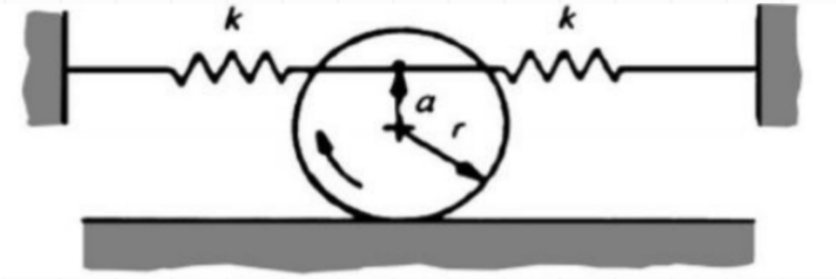

#### Parte a
Aproximando  el  movimiento  a ángulos  muy  pequeños,  encuentre  las  ecuaciones que 
describen  el  movimiento  del  disco  uniforme  de  masa  m  respecto  a  su  punto  de  equilibrio. 
Encuentre  una  expresión  para  su  frecuencia  natural  en  términos  de  las  variables  del 
problema.
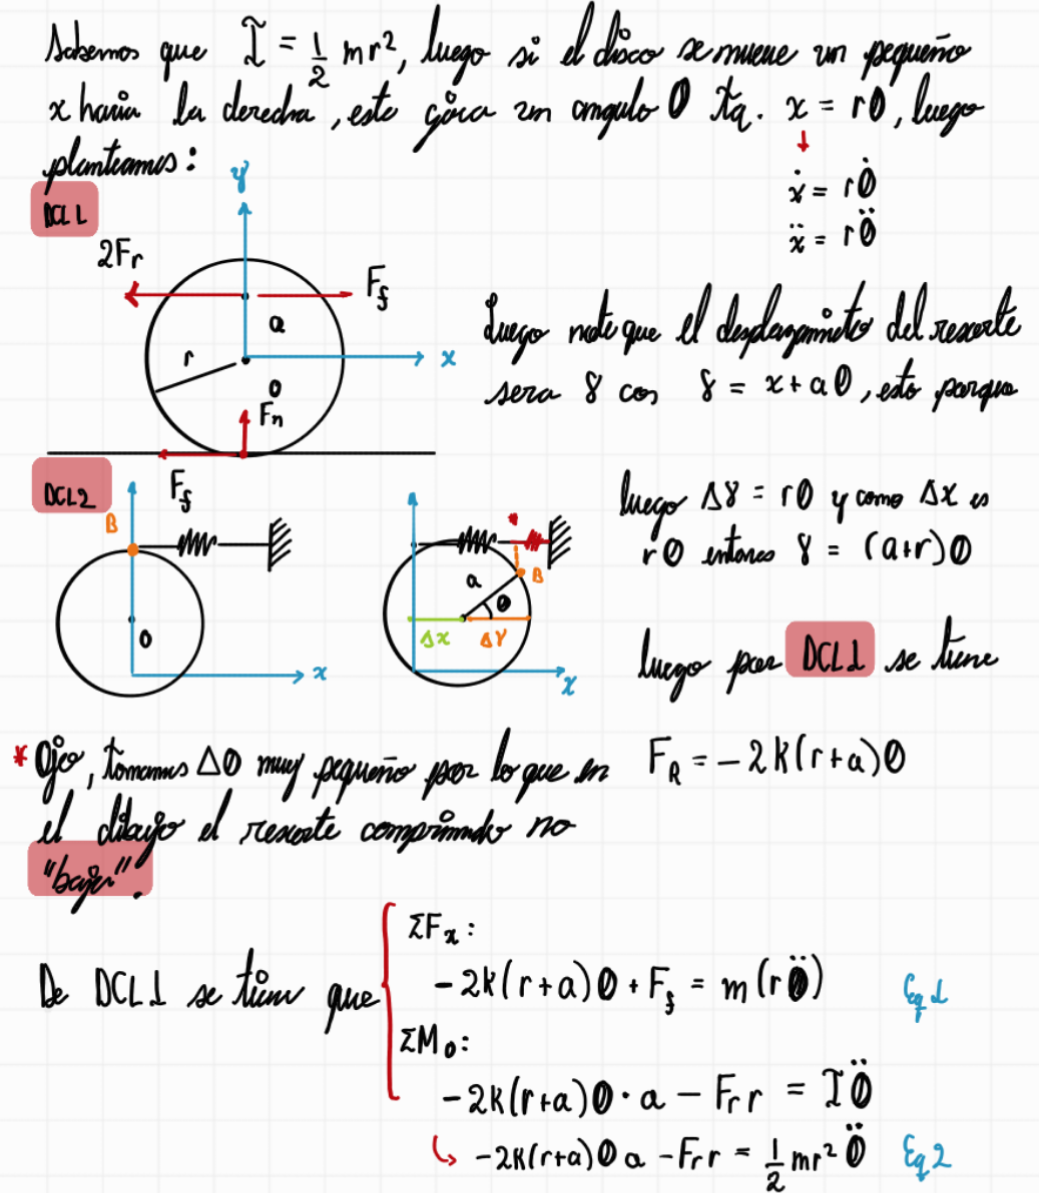
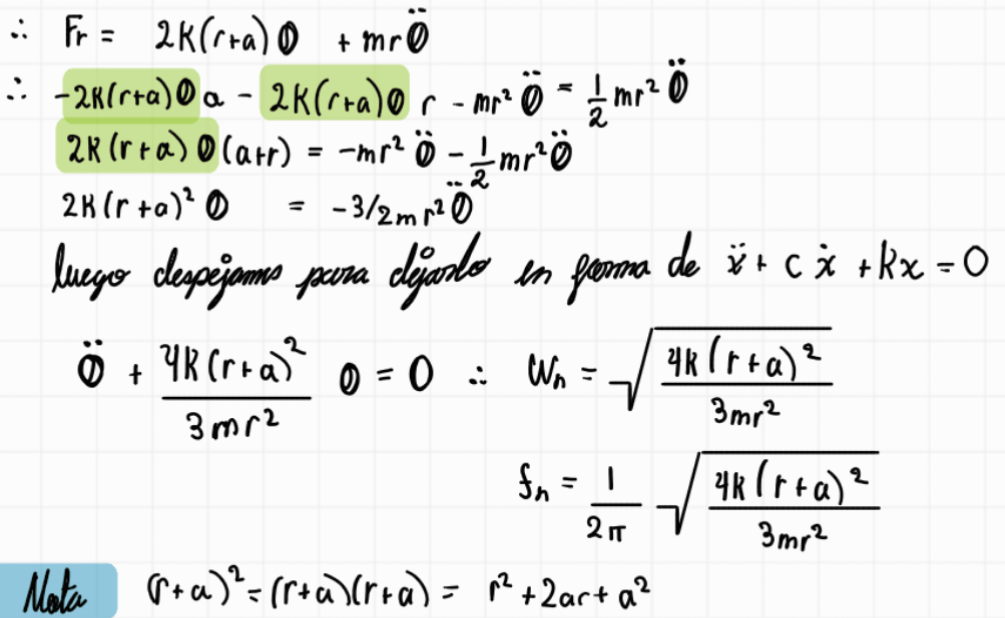

In [59]:
theta = dynamicsymbols('theta')
t = symbols('t')

thetadot = theta.diff(t)
thdd = theta.diff(t, 2)
display(thdd)

m, r, a, k = symbols('m r a k', positive=True)
Ff = symbols('Ff')

eq_T = Eq(-2*k*(r + a)*theta + Ff, m*r*thdd)
eq_R = Eq(-2*k*(r + a)*theta*a - Ff*r, (0.5)*m*r**2 * thdd)

sol = solve([eq_T, eq_R], [Ff, thdd], dict=True)[0]

thdd_expr = simplify(sol[thdd])
Ff_expr   = simplify(sol[Ff])

omega2 = simplify(-thdd_expr/theta)
omega  = simplify(sqrt(omega2))

print("θ̈ (symbolic):")
display(Eq(thdd, factor(thdd_expr)))

print("\nFriction force F_f:")
display(Eq(Ff, factor(Ff_expr)))

print("\nStandard form:")
display(Eq(thdd + factor(omega2)*theta, 0))

print("\nNatural frequency ω:")
display(factor(omega))

print("\nNatural frequency f:")
display(factor(omega/(2*pi)))



θ̈

θ̈ (symbolic):


                                       2   
    -1.33333333333333⋅k⋅(1.0⋅a + 1.0⋅r) ⋅θ 
θ̈ = ───────────────────────────────────────
                        2                  
                     m⋅r                   


Friction force F_f:


     1.33333333333333⋅k⋅(-1.0⋅a + 0.5⋅r)⋅(1.0⋅a + 1.0⋅r)⋅θ
Ff = ─────────────────────────────────────────────────────
                               r                          

...

                                  2          
1.33333333333333⋅k⋅(1.0⋅a + 1.0⋅r) ⋅θ        
───────────────────────────────────── + θ̈ = 0
                   2                         
                m⋅r                          


Natural frequency ω:


1.15470053837925⋅√k⋅(1.0⋅a + 1.0⋅r)
───────────────────────────────────
               √m⋅r                


Natural frequency f:


0.577350269189626⋅√k⋅(1.0⋅a + 1.0⋅r)
────────────────────────────────────
               π⋅√m⋅r               

#### Parte b
Para  el  mismo  sistema  anterior,  suponga  que  se  tiene  una  fuerza  disipativa  de  fricción  de 
rodadura  proporcional  a  la  velocidad  angular  del  disco.  F=c*thetadot.  Teniendo  m=1.0kg, 
r=10cm,  a=2r/3,  c=1.2  Nms/rad.  Encuentre  una  constante  para  los  resortes  que  garantiza 
que su sistema tiene una frecuencia de resonancia superior a 5Hz. Presente la validez de su 
diseño a través de una gráfica de coeficiente de magnificación.
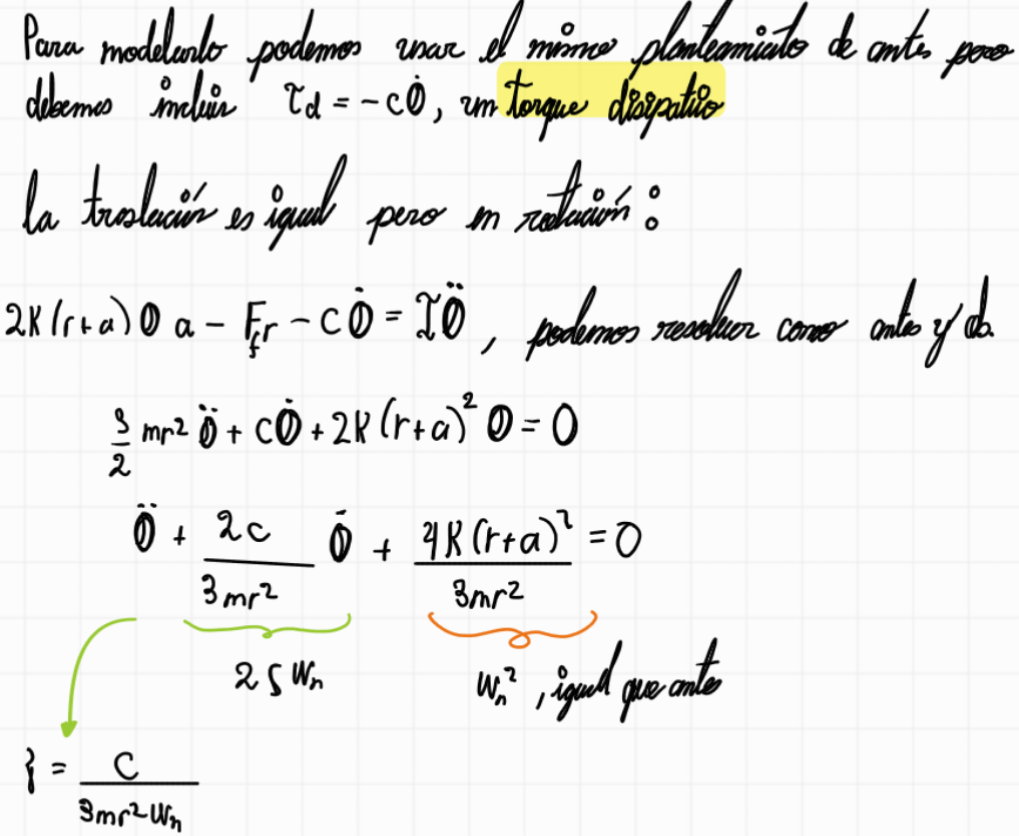

In [60]:
theta = dynamicsymbols('theta')
t = symbols('t')

thetadot = theta.diff(t)
thdd     = theta.diff(t, 2)

m, r, a, k, c = symbols('m r a k c', positive=True)
Ff = symbols('Ff')

eq_T = Eq(-2*k*(r + a)*theta + Ff, m*r*thdd)

eq_R = Eq(-2*k*(r + a)*theta*a - Ff*r - c*thetadot, (0.5)*m*r**2 * thdd)

sol = solve([eq_T, eq_R], [Ff, thdd], dict=True)[0]

thdd_expr = simplify(sol[thdd])
Ff_expr   = simplify(sol[Ff])

eq_std = simplify(thdd_expr/theta)

omega2 = factor(eq_std)                 
damp   = factor((sol[thdd] + (omega2*theta))/thetadot)   

print("θ̈ (symbolic):")
display(Eq(thdd, factor(thdd_expr)))

print("\nFriction force F_f:")
display(Eq(Ff, factor(Ff_expr)))

print("\nStandard form:")
display(Eq(thdd + damp*thetadot + omega2*theta, 0))

print("\nNatural frequency ω_n:")
display(factor(sqrt(omega2)))

print("\nDamping coefficient term (2ζω_n):")
display(damp)


θ̈ (symbolic):


                      ⎛     2                                       2  ⎞ 
    -2.66666666666667⋅⎝0.5⋅a ⋅k⋅θ + 1.0⋅a⋅k⋅r⋅θ + 0.25⋅c⋅θ̇ + 0.5⋅k⋅r ⋅θ⎠ 
θ̈ = ─────────────────────────────────────────────────────────────────────
                                       2                                 
                                    m⋅r                                  


Friction force F_f:


                      ⎛       2                                      2  ⎞
     1.33333333333333⋅⎝- 1.0⋅a ⋅k⋅θ - 0.5⋅a⋅k⋅r⋅θ - 0.5⋅c⋅θ̇ + 0.5⋅k⋅r ⋅θ⎠
Ff = ────────────────────────────────────────────────────────────────────
                                      r                                  


Standard form:


        ⎛     2                                       2  ⎞    
    8.0⋅⎝0.5⋅a ⋅k⋅θ + 1.0⋅a⋅k⋅r⋅θ + 0.25⋅c⋅θ̇ + 0.5⋅k⋅r ⋅θ⎠    
θ̈ - ────────────────────────────────────────────────────── = 0
                                2                             
                             m⋅r                              


Natural frequency ω_n:


                     ______________________________________________
                    ╱        2                 0.25⋅c⋅θ̇          2 
1.63299316185545⋅  ╱  - 0.5⋅a ⋅k - 1.0⋅a⋅k⋅r - ──────── - 0.5⋅k⋅r  
                 ╲╱                               θ                
───────────────────────────────────────────────────────────────────
                               √m⋅r                                


Damping coefficient term (2ζω_n):


                  ⎛     2                                       2  ⎞ 
-5.33333333333333⋅⎝0.5⋅a ⋅k⋅θ + 1.0⋅a⋅k⋅r⋅θ + 0.25⋅c⋅θ̇ + 0.5⋅k⋅r ⋅θ⎠ 
─────────────────────────────────────────────────────────────────────
                                  2                                  
                               m⋅r ⋅θ̇                                

k mínimo requerido:


266.479318829413

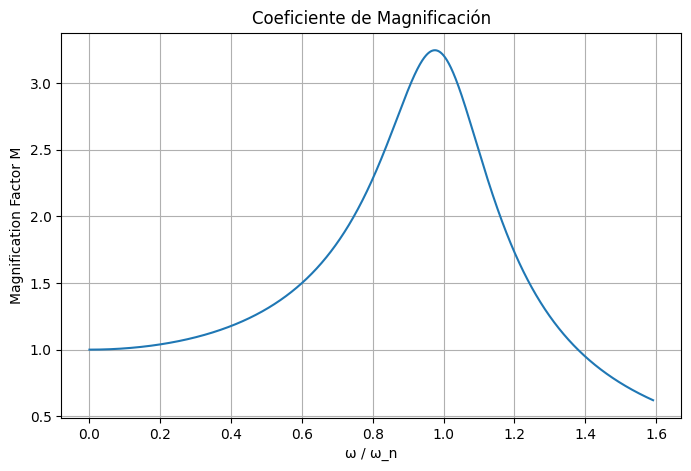

In [61]:
# Datos del sistema
m = 1.0
r = 0.10
a = 2*r/3
c = 1.2

k = symbols('k', positive=True)

f_req = 5

fn_expr = (1/(2*pi))*((4*k*(r+a)**2)/(3*m*r**2))**0.5

k_min = solve(Eq(fn_expr, f_req), k)[0]

print("k mínimo requerido:")
display(k_min)

# Coeficiente de magnificación

omega_n = 2*np.pi*float(f_req)   # aseguramos diseño > 5 Hz
k_use = float(k_min)

# Amortiguamiento equivalente 
zeta = c / (2 * (3/2 * m * r**2)**0.5 * omega_n)

# Frecuencia para graficar
omega = np.linspace(0, 50, 2000)
r_freq = omega / omega_n

# magnification factor
M = 1 / np.sqrt((1 - r_freq**2)**2 + (2*zeta*r_freq)**2)

plt.figure(figsize=(8,5))
plt.plot(r_freq, M)
plt.xlabel('ω / ω_n')
plt.ylabel('Magnification Factor M')
plt.title('Coeficiente de Magnificación')
plt.grid(True)
plt.show()


### Ej 2 
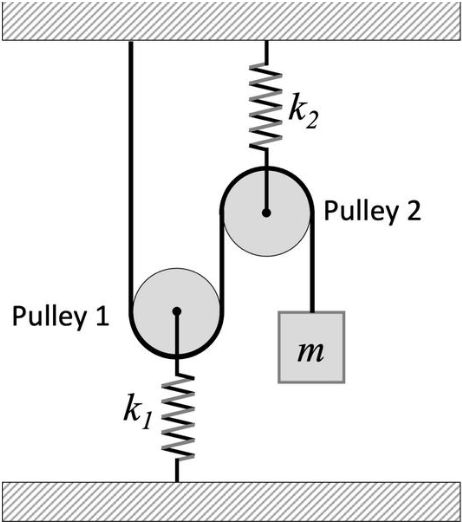

#### Parte a
Para el sistema mostrado las poleas no tienen fricción y son de masa despreciable. La masa 
es  de  8kg  y  los  resortes  k1,k2,  de  800  y  200  N/m  respectivamente.  Calcule  la  frecuencia 
natural del sistema y grafique el movimiento de la masa m cuando se libera desde el reposo 
0.1 cm debajo de su posición de equilibrio.
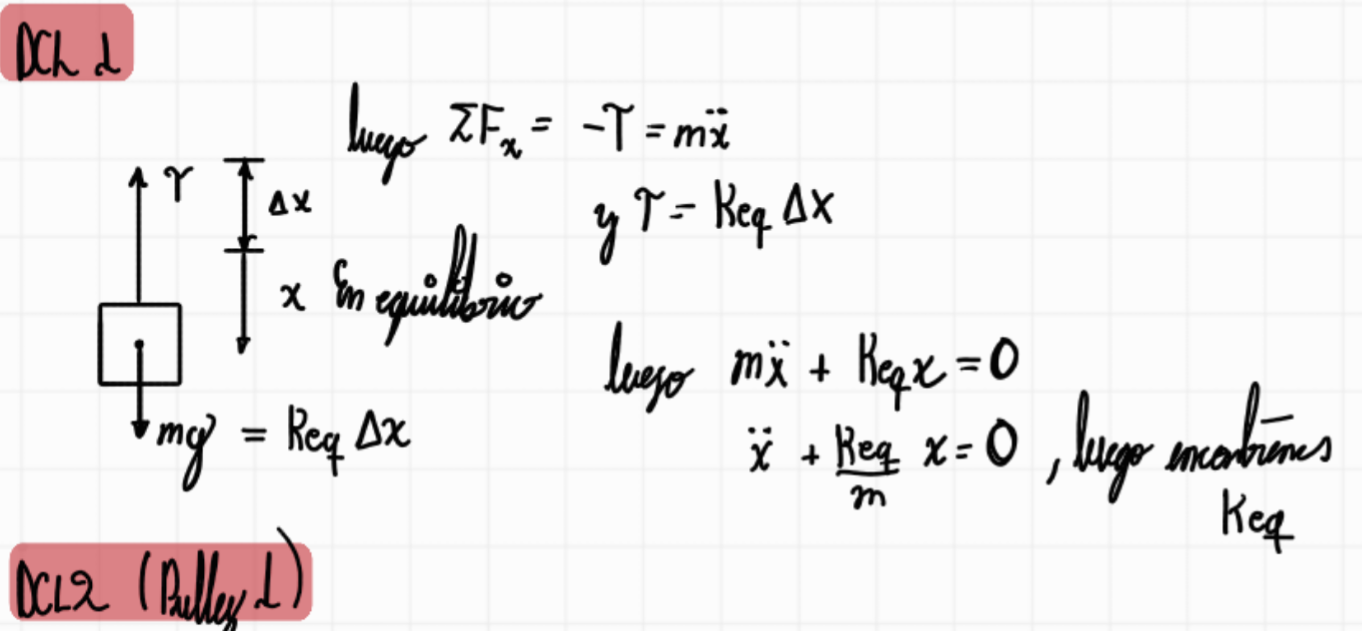
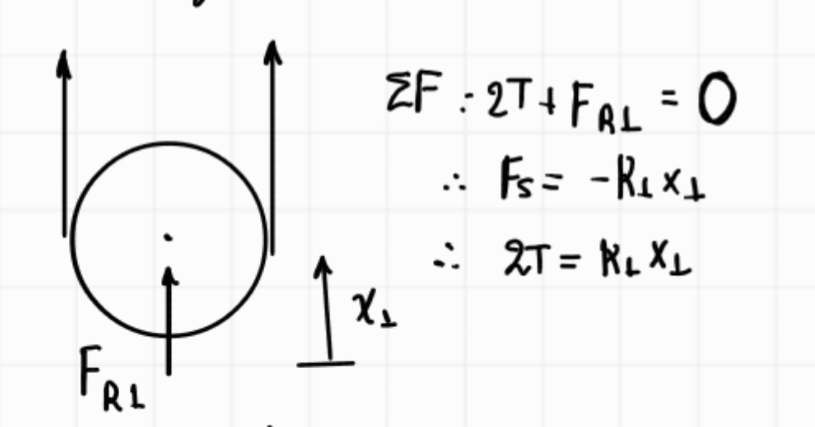
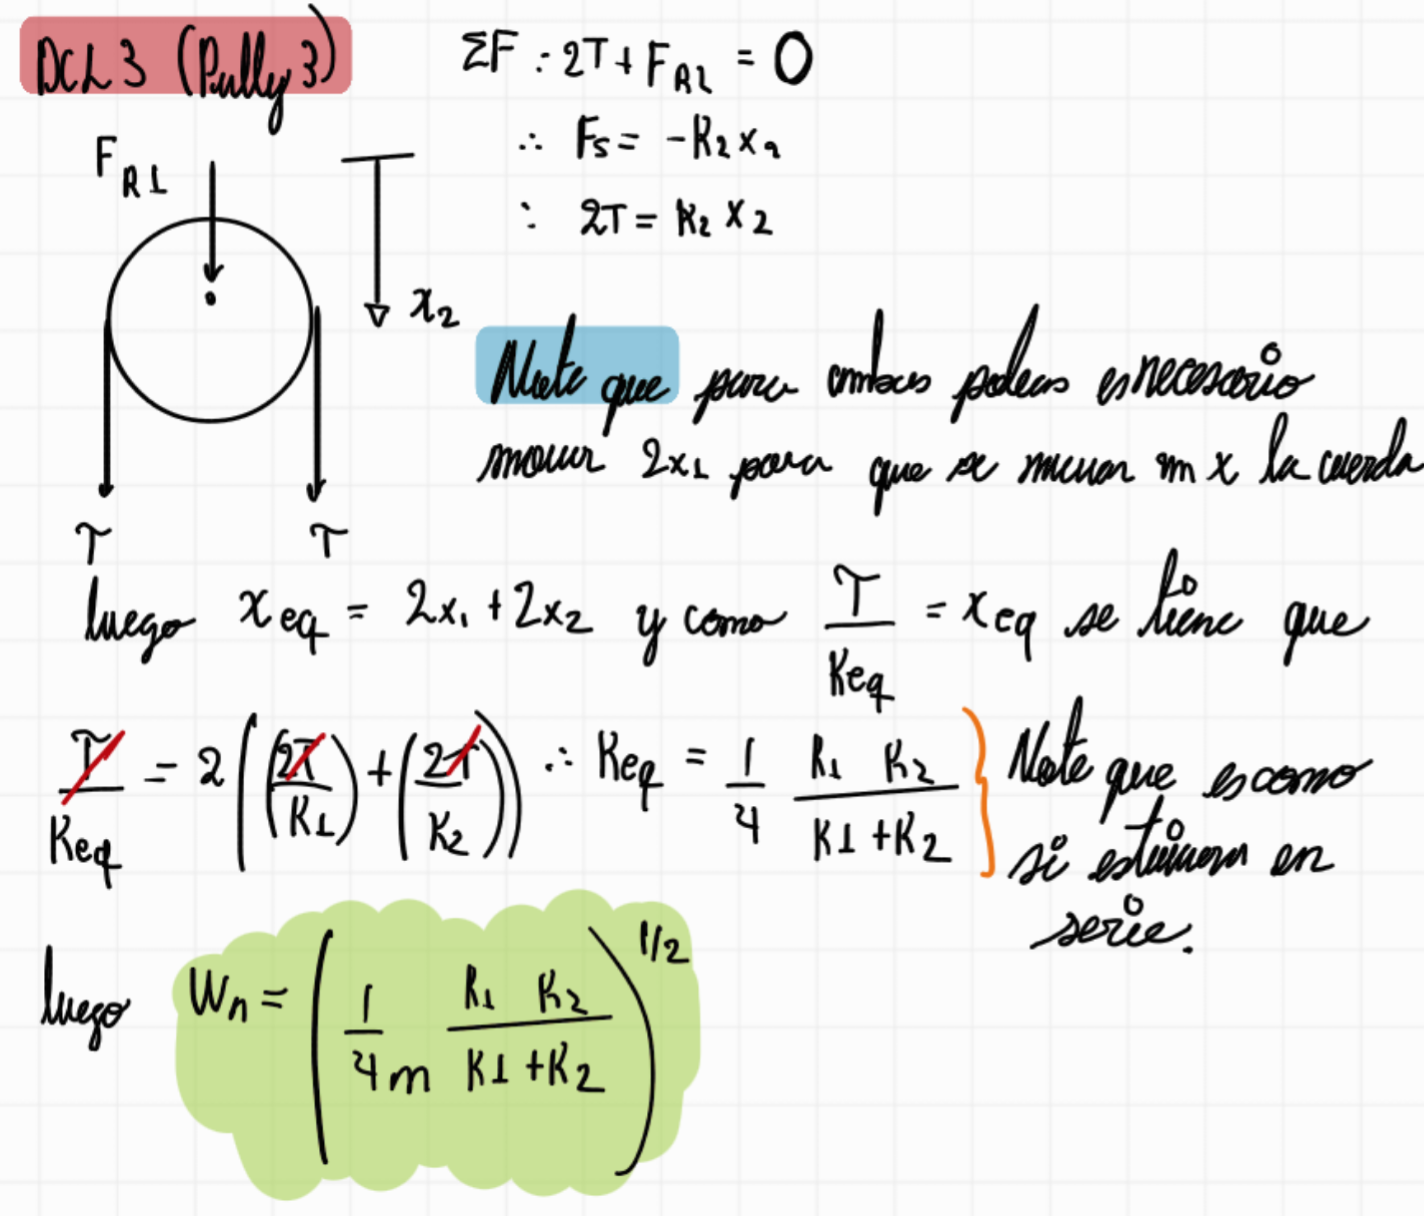

In [62]:
T, x, x1, x2, k1, k2 = symbols('T x x1 x2 k1 k2', positive=True)

eq1 = Eq(2*T, k1*x1)
eq2 = Eq(2*T, k2*x2)

solution = solve([eq1, eq2], [x1, x2])

x1_expr = solution[x1]
x2_expr = solution[x2]

x_relation = Eq(x, 2*x1_expr + 2*x2_expr)

k_eq_sym = simplify(T / (x_relation.rhs / x_relation.lhs))

display(k_eq_sym)


  k₁⋅k₂⋅x  
───────────
4⋅(k₁ + k₂)

   k₁⋅k₂   
───────────
4⋅(k₁ + k₂)

   ____   ____  
 ╲╱ k₁ ⋅╲╱ k₂   
────────────────
       _________
2⋅√m⋅╲╱ k₁ + k₂ 

                     ____   ____
0.0795774715459477⋅╲╱ k₁ ⋅╲╱ k₂ 
────────────────────────────────
              _________         
         √m⋅╲╱ k₁ + k₂          

40.0 2.23606797749979 0.3558812717085886


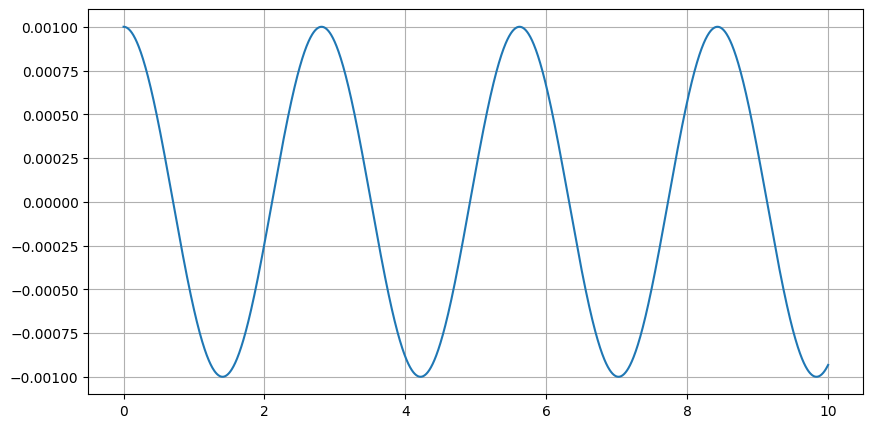

In [63]:
m, k1, k2 = symbols('m k1 k2', positive=True)

k_eq = simplify(k1*k2 / (4*(k1 + k2)))
omega_n = simplify(sqrt(k_eq/m))
f_n = simplify(omega_n/(2*np.pi))

display(k_eq)
display(omega_n)
display(f_n)

m_val = 8.0
k1_val = 800.0
k2_val = 200.0

k_eq_val = float(k_eq.subs({k1:k1_val, k2:k2_val}))
omega_val = float(omega_n.subs({k1:k1_val, k2:k2_val, m:m_val}))
f_val = omega_val/(2*np.pi)

print(k_eq_val, omega_val, f_val)

x0 = 0.001
v0 = 0.0

A = x0
B = v0/omega_val

t = np.linspace(0, 10, 2000)
x = A*np.cos(omega_val*t) + B*np.sin(omega_val*t)

plt.figure(figsize=(10,5))
plt.plot(t, x)
plt.grid()
plt.show()


#### Parte b
Sobre  el  modelo  del  sistema  anterior  incluya  un  término  de  fuerza  disipativa  de  la  forma 
c*xdot, donde xdot corresponde a la velocidad de la masa d. Proponga un valor de c tal que 
su sistema alcance el reposo en menos de 10 segundos.
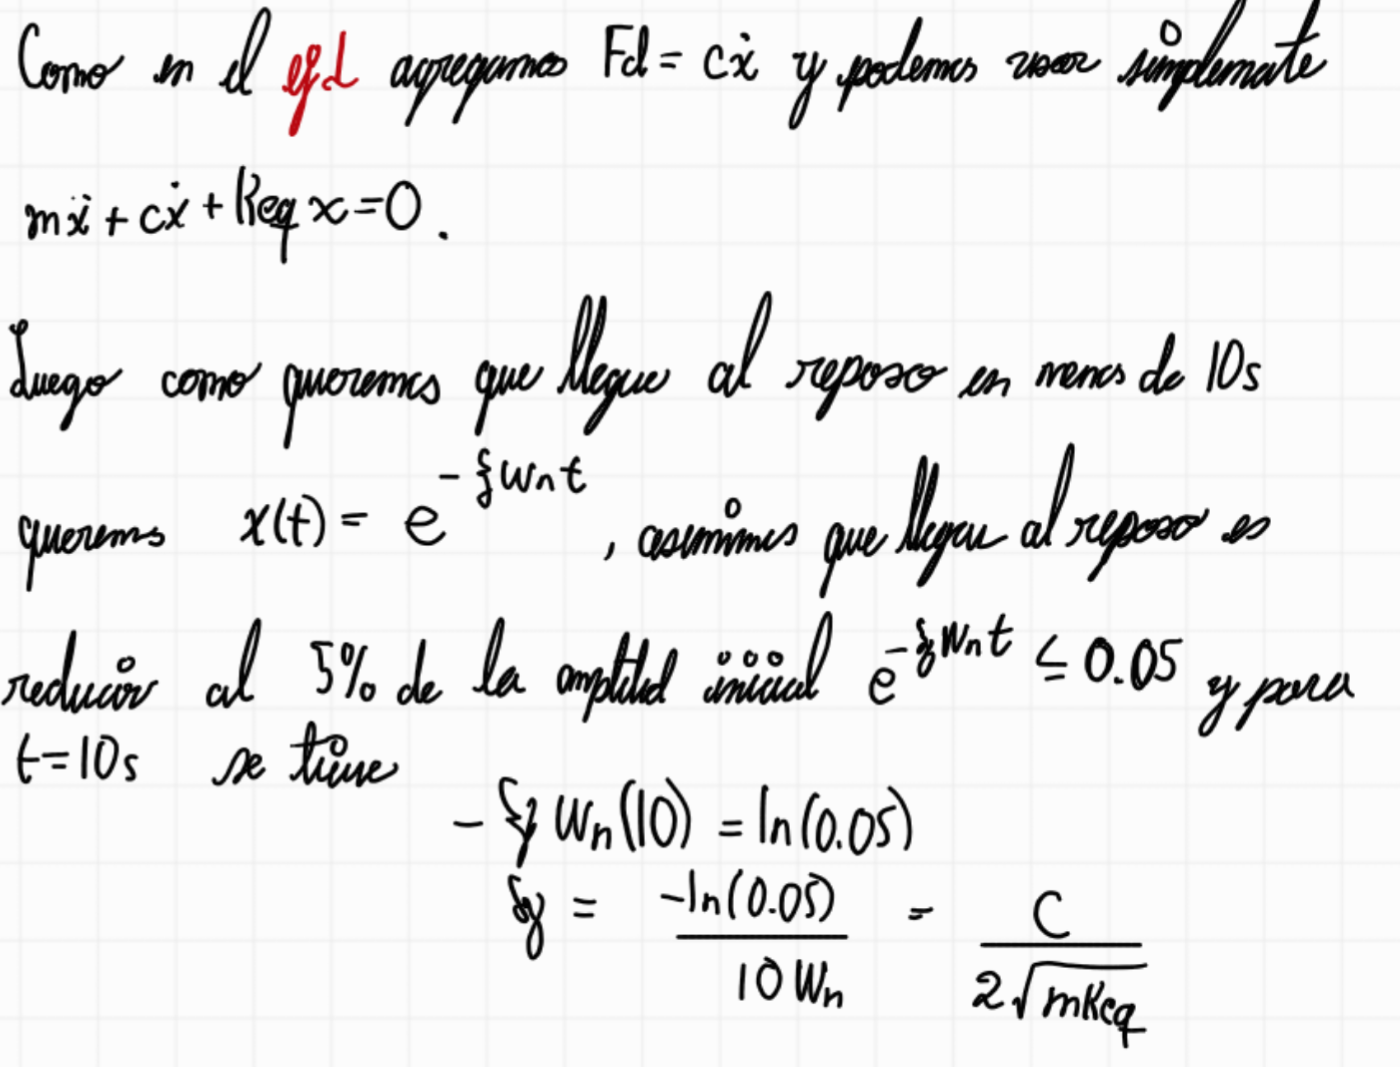

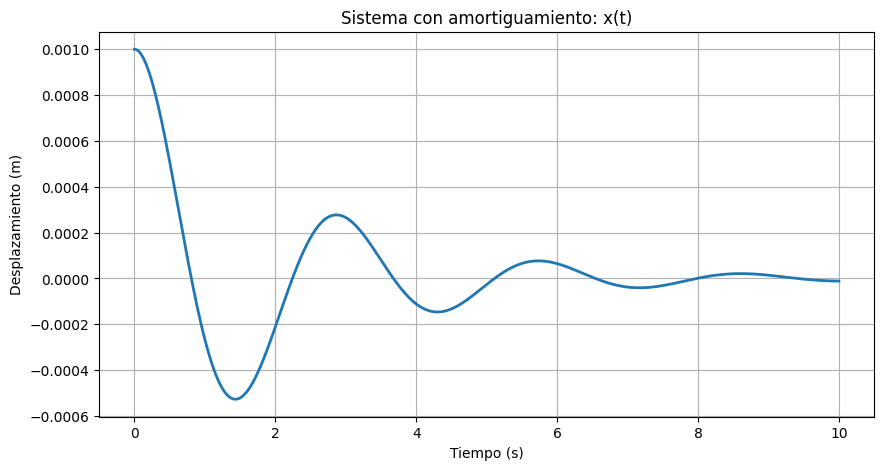

c = 7.155417527999328


In [64]:
m, k1, k2 = symbols('m k1 k2', positive=True)

k_eq = simplify(k1*k2 / (4*(k1 + k2)))
omega_n = simplify(sqrt(k_eq/m))

m_val = 8.0
k1_val = 800.0
k2_val = 200.0

k_eq_val = float(k_eq.subs({k1:k1_val, k2:k2_val}))
omega_n_val = float(omega_n.subs({k1:k1_val, k2:k2_val, m:m_val}))

zeta = 0.2
c = 2*zeta*m_val*omega_n_val

omega_d = omega_n_val*np.sqrt(1 - zeta**2)

x0 = 0.001
v0 = 0.0

t = np.linspace(0, 10, 2000)

x = np.exp(-zeta*omega_n_val*t) * (
        x0*np.cos(omega_d*t) +
        (v0 + zeta*omega_n_val*x0)/omega_d * np.sin(omega_d*t)
)

plt.figure(figsize=(10,5))
plt.plot(t, x, linewidth=2)
plt.title("Sistema con amortiguamiento: x(t)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Desplazamiento (m)")
plt.grid(True)
plt.show()

print("c =", c)


#### Parte c
Para la masa en reposo, se aplica una fuerza senoidal de la forma Fext=3*(sin(wt))  N. y se 
requiere que la masa oscile menos de 2cm. Revise si se cumple con el valor de c propuesto 
en el caso anterior y ajuste a este nuevo requerimiento de ser necesario.

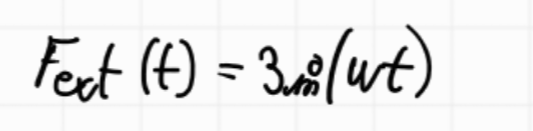
 

In [65]:
t = symbols('t')
x = dynamicsymbols('x')        # x, ẋ, ẍ como símbolos dinámicos
xdot = x.diff(t)
xdd = x.diff(t,2)

m, c, F0, omega = symbols('m c F0 omega', positive=True)
k = symbols('k', positive=True)

ode = Eq(m*xdd + c*xdot + k*x, F0*sin(omega*t))
display(ode)

omega_n = simplify(sqrt(k/m))
zeta = simplify(c/(2*sqrt(m*k)))
omega_d = simplify(omega_n*sqrt(1 - zeta**2))

X = simplify(F0 / sqrt((k - m*omega**2)**2 + (c*omega)**2))

display(Eq(symbols('omega_n'), omega_n))
display(Eq(symbols('zeta'), zeta))
display(Eq(symbols('omega_d'), omega_d))
display(Eq(symbols('X_omega'), X))


c⋅ẋ + k⋅x + m⋅ẍ = F₀⋅sin(ω⋅t)

     √k
ωₙ = ──
     √m

       c   
ζ = ───────
    2⋅√k⋅√m

         ______________
        ╱    2         
      ╲╱  - c  + 4⋅k⋅m 
ω_d = ─────────────────
             2⋅m       

                 F₀            
X_ω = ─────────────────────────
          _____________________
         ╱                   2 
        ╱   2  2   ⎛       2⎞  
      ╲╱   c ⋅ω  + ⎝k - m⋅ω ⎠  

k_eq = 40.0
omega_n [rad/s] = 2.23606797749979
f_n [Hz] = 0.3558812717085886

Con c = 7.155417527999328
Amplitud en resonancia X_res = 0.18749999999999997 m

c requerido (para X<=0.02 m en r=1): 67.08203932499369 N·s/m


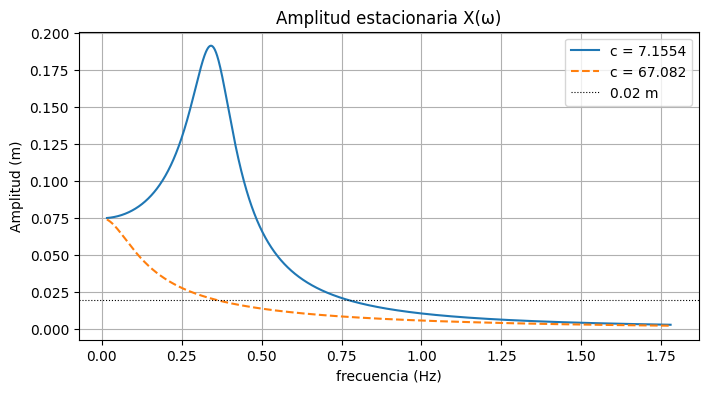

In [66]:
m_val = 8.0
k1_val = 800.0
k2_val = 200.0
F0_val = 3.0

k_eq = float((k1_val*k2_val) / (4*(k1_val + k2_val)))
omega_n_val = np.sqrt(k_eq / m_val)

c_given = 7.155417527999328

# amplitud en resonancia
X_res_given = F0_val / (c_given * omega_n_val)

# c mínimo para mantener X <= 0.02 (worst-case)
X_max_req = 0.02
c_min = F0_val / (X_max_req * omega_n_val)

print("k_eq =", k_eq)
print("omega_n [rad/s] =", omega_n_val)
print("f_n [Hz] =", omega_n_val/(2*np.pi))
print("\nCon c =", c_given)
print("Amplitud en resonancia X_res =", X_res_given, "m")

print("\nc requerido (para X<=0.02 m en r=1):", c_min, "N·s/m")

# Amplitud en función de frecuencia para el c dado y para c_min
omega = np.linspace(0.1, 5*omega_n_val, 2000)
def X_of_omega(omega_arr, c_val):
    return F0_val / np.sqrt((k_eq - m_val*omega_arr**2)**2 + (c_val*omega_arr)**2)

X_given = X_of_omega(omega, c_given)
X_cmin  = X_of_omega(omega, c_min)

plt.figure(figsize=(8,4))
plt.plot(omega/(2*np.pi), X_given, label=f'c = {c_given:.4f}')
plt.plot(omega/(2*np.pi), X_cmin,  '--', label=f'c = {c_min:.3f}')
plt.axhline(0.02, color='k', linewidth=0.8, linestyle=':', label='0.02 m')
plt.xlabel('frecuencia (Hz)')
plt.ylabel('Amplitud (m)')
plt.legend()
plt.grid(True)
plt.title('Amplitud estacionaria X(ω)')
plt.show()


**Análisis**

Partiendo del modelo excitado, obtuve con SymPy la expresión simbólica de la amplitud en estado estacionario. Luego, usando los valores del sistema y el amortiguamiento que habíamos propuesto antes, calculé la amplitud máxima en resonancia. Con c = 7.1554 la respuesta supera el límite de 2 cm, por lo que no cumple el nuevo requisito.
Después calculé el valor mínimo de amortiguamiento necesario imponiendo que la amplitud no supere 0.02 m y lo compare con el valor dado. Finalmente, la gráfica confirma que el c original es insuficiente y que el nuevo c mínimo sí mantiene la oscilación por debajo del límite permitido.
